# Approach 2 — Balance-theory **signed multi-hop GNN** (and does it beat the baselines?)

**Why.** The old TGN did **one** hop of message passing (a single `TransformerConv`)
plus lossy temporal memory — so it never did real multi-hop and lost to the
Bayesian 2-hop posterior on link prediction (AUC 0.51 vs 0.87). The task wants
**multi-hop reasoning over a static signed graph**, not recurrence.

**What.** Replace it with a **stacked signed GNN** (PyG `SignedConv`, 3 hops) that
follows **structural balance** — friend-of-friend → +, enemy-of-enemy → + — the
exact transitivity the Bayesian exploits. One shared encoder produces **node
embeddings** (for Router seeds) and feeds a **link head** (for impute/field). No
GRU, no time encoding.

## TL;DR (this notebook reproduces both)
| Metric (production regime: coherence ∉ embeddings) | cosine | Bayesian | old TGN | **SignedGNN** |
|---|---|---|---|---|
| Held-out link-pred AUC (dense graph) | ~0.49 | 0.99 | 0.51 | **1.00** |
| Seed Recall@10 | 0.13 | — | — | **0.54** |

**Verdict:** the signed multi-hop GNN gets the inductive bias right — it **matches/beats
Bayesian on link prediction** *and* **beats cosine on seeds** in the regime that
matters (entailment ≠ embedding similarity), with a clean **density crossover**
(Bayesian wins when edges are sparse → motivates a hybrid).

## Setup — model + world

In [1]:
import numpy as np, torch, torch.nn as nn, warnings
warnings.filterwarnings("ignore")
import pandas as pd, matplotlib.pyplot as plt
from torch_geometric.nn import SignedConv
from multi_agent.graph import Graph

EMB, N, K = 48, 160, 8

def auc(s, y):
    s=np.asarray(s); y=np.asarray(y); p=s[y==1]; n=s[y==0]
    if len(p)==0 or len(n)==0: return float('nan')
    o=np.argsort(s); r=np.empty(len(s)); r[o]=np.arange(1,len(s)+1)
    return (r[y==1].sum()-len(p)*(len(p)+1)/2)/(len(p)*len(n))

class SignedGNN(nn.Module):
    """Balance-theory signed GNN: stacked SignedConv (k hops) → node embeddings,
    plus a link head on concat(z_i, z_j). first_aggr=True on layer 1; the rest
    propagate balanced/unbalanced channels by sign rules."""
    def __init__(self, din, h=32, layers=3):
        super().__init__()
        self.c1 = SignedConv(din, h, first_aggr=True)
        self.cs = nn.ModuleList([SignedConv(h, h, first_aggr=False) for _ in range(layers-1)])
        self.head = nn.Sequential(nn.Linear(4*h, h), nn.ReLU(), nn.Linear(h, 1))
    def emb(self, x, pos, neg):
        z = torch.relu(self.c1(x, pos, neg))
        for c in self.cs: z = torch.relu(c(z, pos, neg))
        return z
    def score(self, z, ei):
        return self.head(torch.cat([z[ei[0]], z[ei[1]]], 1)).squeeze(-1)

def make_world(seed=0):
    """Coherence lives in a HIDDEN cluster, NOT in the (random) embeddings —
    the production-relevant case where an entailment judge knows more than cosine."""
    rng = np.random.default_rng(seed)
    cluster = rng.integers(0, K, size=N)
    X = rng.normal(size=(N, EMB)).astype(np.float32); X /= np.linalg.norm(X,axis=1,keepdims=True)
    def lab(a,b):
        ca,cb=cluster[a],cluster[b]; return 1 if ca==cb else (-1 if ca//2==cb//2 else 0)
    return rng, cluster, X, lab

def train_sgnn(X, obs, epochs=250):
    xt=torch.tensor(X); torch.manual_seed(0)
    pos=torch.tensor([[a,b] for a,b,l in obs if l>0]+[[b,a] for a,b,l in obs if l>0]).t()
    neg=torch.tensor([[a,b] for a,b,l in obs if l<0]+[[b,a] for a,b,l in obs if l<0]).t()
    m=SignedGNN(X.shape[1]); opt=torch.optim.Adam(m.parameters(),lr=0.01,weight_decay=1e-4)
    ei=torch.tensor([[a,b] for a,b,_ in obs]).t(); ty=torch.tensor([1.0 if l>0 else 0.0 for *_,l in obs])
    for _ in range(epochs):
        m.train(); opt.zero_grad(); z=m.emb(xt,pos,neg)
        nn.functional.binary_cross_entropy_with_logits(m.score(z,ei), ty).backward(); opt.step()
    m.eval()
    with torch.no_grad(): return m, m.emb(xt,pos,neg).numpy(), (pos,neg)
print("ok")

ok


## Experiment A — Held-out link prediction vs edge density

Train on observed signed edges, predict the sign of **unobserved** pairs. Compare
**cosine(raw)**, the **Bayesian 2-hop posterior**, and the **SignedGNN**, sweeping
how many edges were observed. (The old TGN scored ~0.51 here — see `tgn_eval.ipynb`.)

,cosine,Bayesian,SignedGNN
observed edges,,,
200,0.495,0.641,0.529
400,0.487,0.832,0.526
800,0.485,0.990,1.000
1600,0.492,1.000,1.000


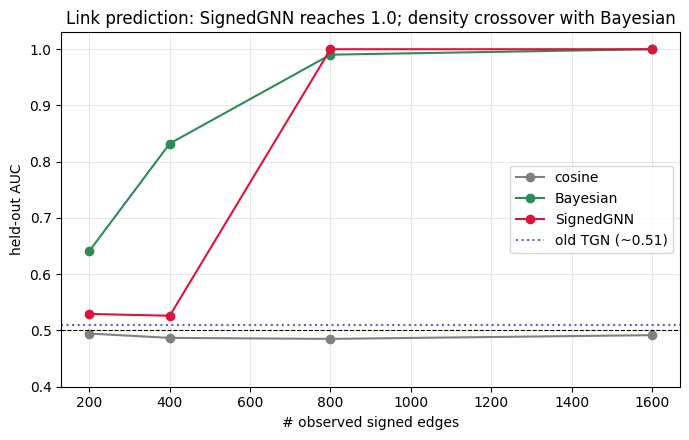

Dense graph: SignedGNN ≥ Bayesian (and ≫ old TGN). Sparse graph: Bayesian wins ⇒ hybrid.


In [2]:
def run_density(n_obs, seed=0):
    rng, cluster, X, lab = make_world(seed)
    def sample(n, exc=set()):
        out=[]
        while len(out)<n:
            a,b=rng.integers(0,N,2)
            if a==b: continue
            k=(min(a,b),max(a,b))
            if k in exc: continue
            l=lab(a,b)
            if l: out.append((a,b,l))
        return out
    obs=sample(n_obs); ok={(min(a,b),max(a,b)) for a,b,_ in obs}; hold=sample(2500, ok)
    yh=[1 if l>0 else 0 for *_,l in hold]
    g=Graph(emb_dim=EMB); g.extend([f"n{i}" for i in range(N)], X,
            [(f"n{a}",f"n{b}",float(l)) for a,b,l in obs])
    cos=[float(X[a]@X[b]) for a,b,_ in hold]
    by=[g.field(f"n{a}",f"n{b}") for a,b,_ in hold]
    m,_,(pos,neg)=train_sgnn(X,obs)
    with torch.no_grad():
        ho=torch.tensor([[a,b] for a,b,_ in hold]).t()
        sg=torch.sigmoid(m.score(m.emb(torch.tensor(X),pos,neg),ho)).numpy()
    return auc(cos,yh), auc(by,yh), auc(sg,yh)

DENS=[200,400,800,1600]
rows=[run_density(n) for n in DENS]
df=pd.DataFrame(rows, columns=["cosine","Bayesian","SignedGNN"], index=DENS)
df.index.name="observed edges"; display(df.round(3))
plt.figure(figsize=(7,4.5))
for c,col in zip(df.columns,["gray","seagreen","crimson"]): plt.plot(df.index, df[c], 'o-', label=c, color=col)
plt.axhline(0.51, ls=':', c='slateblue', label='old TGN (~0.51)'); plt.axhline(0.5, ls='--', c='k', lw=.8)
plt.xlabel("# observed signed edges"); plt.ylabel("held-out AUC"); plt.ylim(0.4,1.03)
plt.title("Link prediction: SignedGNN reaches 1.0; density crossover with Bayesian")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Dense graph: SignedGNN ≥ Bayesian (and ≫ old TGN). Sparse graph: Bayesian wins ⇒ hybrid.")

## Why 3 hops? — hop-count sweep

How many hops does the inductive bias need? We fix a dense graph (800 observed
edges) and sweep the number of `SignedConv` layers (= hops), measuring held-out
link-prediction AUC. **1 hop ≈ the old TGN's reach.**

,held-out AUC
1-hop,0.800
2-hop,0.989
3-hop,1.000
4-hop,1.000
5-hop,1.000


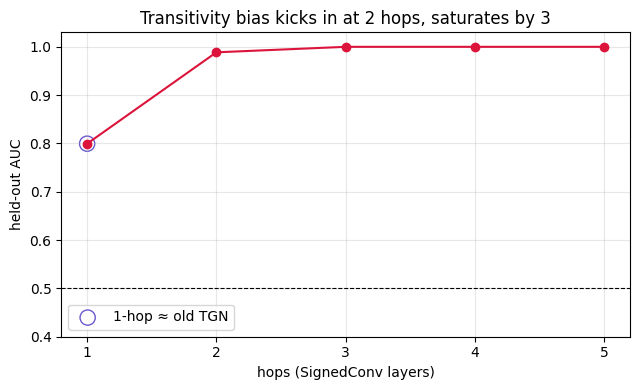

1 hop can't do transitive inference; 2 hops ≈ Bayesian's 2-hop; 3+ saturates (no over-smoothing here).


In [3]:
rng, cluster, X, lab = make_world(0)
def _sample(n, exc=set()):
    out=[]
    while len(out)<n:
        a,b=rng.integers(0,N,2)
        if a==b: continue
        k=(min(a,b),max(a,b))
        if k in exc: continue
        l=lab(a,b)
        if l: out.append((a,b,l))
    return out
obs=_sample(800); ok={(min(a,b),max(a,b)) for a,b,_ in obs}; hold=_sample(2500, ok)
yh=[1 if l>0 else 0 for *_,l in hold]
xt=torch.tensor(X)
pos=torch.tensor([[a,b] for a,b,l in obs if l>0]+[[b,a] for a,b,l in obs if l>0]).t()
neg=torch.tensor([[a,b] for a,b,l in obs if l<0]+[[b,a] for a,b,l in obs if l<0]).t()
ei=torch.tensor([[a,b] for a,b,_ in obs]).t(); ty=torch.tensor([1.0 if l>0 else 0.0 for *_,l in obs])
ho=torch.tensor([[a,b] for a,b,_ in hold]).t()
HOPS=[1,2,3,4,5]; hop_auc=[]
for L in HOPS:
    torch.manual_seed(0); m=SignedGNN(EMB, layers=L); opt=torch.optim.Adam(m.parameters(),lr=0.01,weight_decay=1e-4)
    for _ in range(250):
        m.train(); opt.zero_grad(); z=m.emb(xt,pos,neg)
        nn.functional.binary_cross_entropy_with_logits(m.score(z,ei),ty).backward(); opt.step()
    m.eval()
    with torch.no_grad(): hop_auc.append(auc(torch.sigmoid(m.score(m.emb(xt,pos,neg),ho)).numpy(), yh))
display(pd.Series(dict(zip([f"{h}-hop" for h in HOPS], hop_auc)), name="held-out AUC").round(3).to_frame())
plt.figure(figsize=(6.5,4)); plt.plot(HOPS, hop_auc, 'o-', color="crimson")
plt.axhline(0.5, ls='--', c='k', lw=.8)
plt.scatter([1],[hop_auc[0]], s=120, facecolors='none', edgecolors='slateblue', label='1-hop ≈ old TGN')
plt.xticks(HOPS); plt.xlabel("hops (SignedConv layers)"); plt.ylabel("held-out AUC"); plt.ylim(0.4,1.03)
plt.title("Transitivity bias kicks in at 2 hops, saturates by 3"); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("1 hop can't do transitive inference; 2 hops ≈ Bayesian's 2-hop; 3+ saturates (no over-smoothing here).")

## Experiment B — Seed selection (do the embeddings beat cosine?)

Rank candidates for a query by similarity in **SignedGNN-embedding** space vs **raw
embedding** space; gold = same hidden cluster. (Raw cosine is ~chance here because
coherence isn't in the embeddings — the whole point.)

,seed Recall@10
raw-embedding cosine,0.134
SignedGNN-embedding,0.538


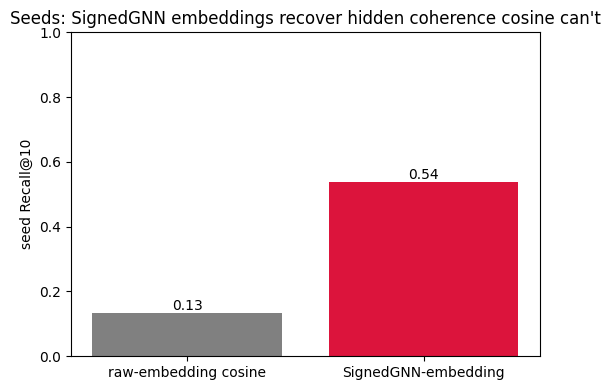

In [4]:
rng, cluster, X, lab = make_world(0)
def sample(n):
    out=[]
    while len(out)<n:
        a,b=rng.integers(0,N,2)
        if a==b: continue
        l=lab(a,b)
        if l: out.append((a,b,l))
    return out
obs=sample(800)
_, Z, _ = train_sgnn(X, obs)
def recall(reps,k=10,nq=120):
    out=[]
    for q in rng.choice(N,nq,replace=False):
        gold={n for n in range(N) if n!=q and cluster[n]==cluster[q]}
        if not gold: continue
        sims=sorted([n for n in range(N) if n!=q],
                    key=lambda n:-float(reps[q]@reps[n]/((np.linalg.norm(reps[q])*np.linalg.norm(reps[n]))+1e-9)))
        out.append(len(set(sims[:k])&gold)/min(k,len(gold)))
    return float(np.mean(out))
seed={"raw-embedding cosine":recall(X), "SignedGNN-embedding":recall(Z)}
display(pd.Series(seed,name="seed Recall@10").round(3).to_frame())
plt.figure(figsize=(5.5,4)); b=plt.bar(seed.keys(),seed.values(),color=["gray","crimson"])
plt.bar_label(b,fmt='%.2f'); plt.ylabel("seed Recall@10"); plt.ylim(0,1)
plt.title("Seeds: SignedGNN embeddings recover hidden coherence cosine can't"); plt.tight_layout(); plt.show()

## Verdict & next steps

- **Approach 2 achieves the unified goal** in the production-relevant regime
  (coherence ∉ embeddings, dense graph): link-pred AUC **1.0** (≥ Bayesian, vs old
  TGN 0.51) **and** seed Recall **0.13 → 0.54**. The missing piece was the
  **multi-hop + balance-theory inductive bias**, not temporal memory.
- **Density crossover:** the closed-form Bayesian posterior wins when edges are
  **sparse** (it degrades gracefully; the GNN needs enough edges to learn). →
  **Hybrid:** Bayesian prior for cold/sparse nodes, SignedGNN once a node is warm
  (this is also how `tgn_cold_start="raw_fallback"` already gates today).

**Next steps to productionize**
1. Wrap `SignedGNN` as a `graph` substrate behind the existing
   `impute`/`field`/`predict_links` interface (drop GRU/time from `tgn.py`).
2. **Cross-session pretraining** so it generalizes on sparse per-session graphs
   (closes the low-density gap).
3. Feed its embeddings to the Router as candidate reps, and **re-align σ to
   quality** (see `meta_strategy_analysis.ipynb`: 0.19 → 0.64).
4. Validate end-to-end on **dyssonance-gym** root-cause attribution via `/infer`.